In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

# Adjust default font size so that labels are readable in plots
font = {'size': 18}
matplotlib.rc('font', **font)
matplotlib.rcParams['savefig.dpi'] = 200
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = [8, 4]

# Probability


## Warm up: the Urn problem


### Introduction
Suppose you have an [urn](https://en.wikipedia.org/wiki/Urn_problem#Historical_remarks)  with a large number of coloured balls, some of which are red balls and some white. 

You draw a ball from the urn, note its colour and replace it in the urn. (The replacement means that the draws are _independent_ , i.e. the previous draws do not affect the current one). 

Let the fraction of red balls in the urn be denoted $\rho$. For now, we will assume that the number of balls in the urn is so large that $\rho$ can be treated as a _continuous_ variable (although in this example, technically it is actually _discrete_ ).

The probability of drawing $r$ red balls from $n$ trials (draws) is given by the [binomial probability distribution](https://en.wikipedia.org/wiki/Binomial_distribution). This was considered by Jacob Bernoulli ([1713](https://en.wikipedia.org/wiki/Ars_Conjectandi)).

In [3]:
def binom(trials,success,p):
        
    import scipy.special as sp
    # Prefactor sp.binom (the binomial coefficient) returns (trials)!/(success! * (trials-success)!)
    return sp.binom(trials, success)*p**success*(1.-p)**(trials-success)

In [4]:
from scipy.stats import norm

def plotbinom(rho, trials, lo=0, hi=None):
    
    if hi is None: hi=trials
    
    # Its also interesting to plot the Normal approximation to the binomial distribution
    mean = trials*rho
    sd = np.sqrt (trials * rho * ( 1. - rho ))
    # Normal distribution from scipy.stats
    rv = norm(loc = mean, scale = sd)

    r = np.linspace(lo,hi, hi-lo+1)
    ##plot(r, binom(trials, r, rho),label='Binomial')
    b = binom(trials, r, rho)
    ##plot(r, rv.pdf(r), label='Normal')
    g = rv.pdf(r)
    plt.bar(r-0.2, b, 0.4, color='b', label='Binomial')
    plt.bar(r+0.2, g, 0.4, color='g', label='Normal')
    plt.legend(loc='upper left')
    plt.xlabel(r'$r$')
    plt.ylabel('Probability')
    print(trials, "trials")

It is interesting (for reasons we will see later) to compare the results from the binomial distribution with those of a Normal distribution function (a Gaussian).

3 trials


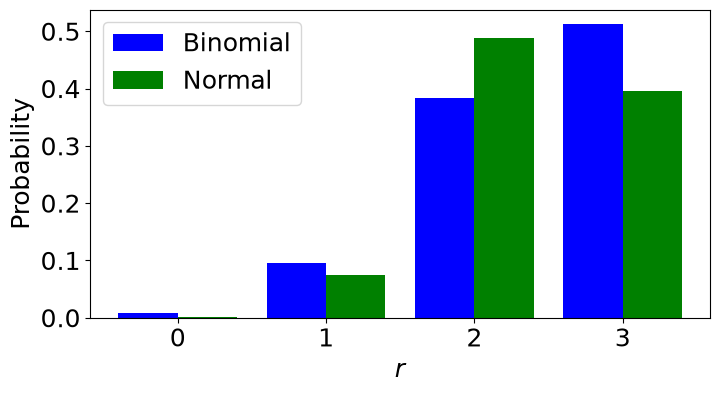

In [5]:
rho = 0.8 # fraction of red balls
plt.xticks(np.arange(0.,4.,1.0))
plotbinom(rho, 3)

So there are four possibilities for the number of red balls, $r$: 0, 1, 2, 3.  Probability of $r=0$ is very low because I would have to pull a white ball 3 times in a row.

### Aside: 

In the plot above the blue (binomial) and green (Normal approximation) curves are different.

But what happens if we crank up the number of trial, to, say, 100?

100 trials


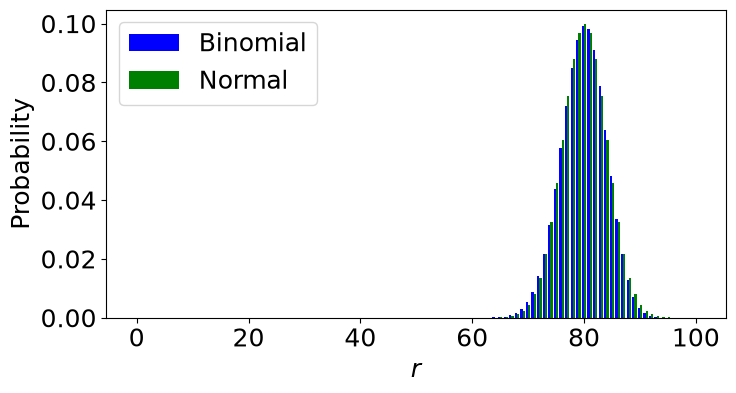

In [6]:
plotbinom(rho, 100)

The distribution approaches a Normal distribution (a Gaussian, or "bell curve"). 

This is a consequence of the *central limit theorem*. 

We are adding random variables. In this case the random variables are discrete: P=0.8 red (1) or P=0.2 white (0). In the limit that the number of things being added is large, you get a Normal shape. The remarkable thing is that it doesn't matter what is the probability distribution of the underlying variable that you are adding.

And since *means* are just sums over all the data (divided by a constant), they follow the central limit theorem if the number of data being averaged is large.

### Back to the main story

So this tells us the probability of getting $r$ successes from $n$ trials.

But in science this is usually **not** what we want ....

What we really want to know is given the number of red balls that we pulled (the _sample_), what is the fraction of red balls in the urn (the _population_).

(The red balls pulled are the _data_ , and the fraction of red balls in the urn $\rho$ is the unknown _model_ parameter).


Suppose you draw a ball 5 times (5 "trials") and the number of reds ("successes") is 4. 

Turn the problem around and consider which choice of $\rho$ maximizes the probability of the observed outcome. Now $\rho$ is the variable, and the numbers of trials and successes are fixed.  

In [7]:
def getrho(trials, success, drho = 0.001):

    rho = np.linspace(0.,1.,int(1./drho))
    drho = rho[1]-rho[0]
    
    prob = binom(trials, success, rho)
    # Normalize it and convert to probability *density*
    prob = prob/np.sum(prob)/drho
    
    return prob, rho
    
def plotrho(trials, success):
    
    prob, rho = getrho(trials, success)
    
    plt.title(str(success)+' successes from '+str(trials)+' trials' )
    plt.xlabel(r'$\rho$')
    plt.ylabel('Prob density')
    plt.plot(rho, prob);
    return

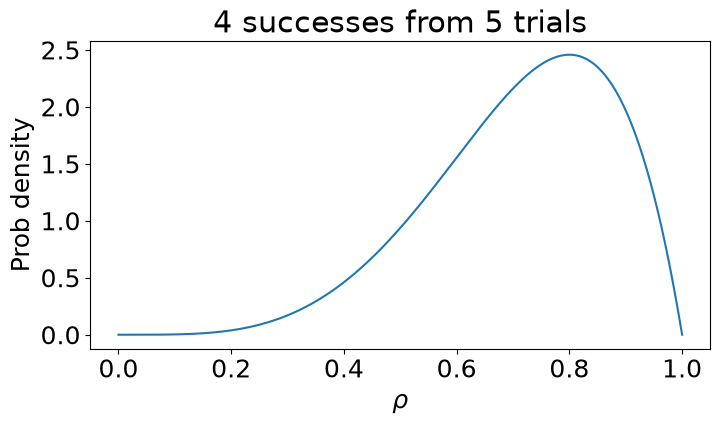

In [8]:
success = 4
trials = 5
plotrho(trials, success)

The fact that the peak is at 0.8 may seem obvious: the most likely value of $\rho$ is the observed fraction.  But of course it is possible that the true fraction of the _population_ is different from the one observed in the  _sample_.  For example, if $\rho = 0.5$ it is possible to pull out 4 red balls in 5 tries. How likely? That's what this course is about ....

Notice that when $\rho$ is a continuous variable it only makes sense to talk about the probability of an *interval* of $\rho$. For example, the probability that $\rho$ is between $0.79$ and $0.81$ is $\approx 2.5 \times 0.02 = 0.05$. 

In [9]:
def prob_int(trials, success, lo, hi):

    from scipy.interpolate import interp1d
    
    prob, rho  = getrho(trials, success)
    drho = rho[1]-rho[0]
    sumprob = np.cumsum(prob)*drho
    f = interp1d(rho, sumprob)
    return f(hi)-f(lo)

In [10]:
print("Probability that rho is between 0.79 and 0.81:", prob_int(5, 4, 0.79,0.81))
print("Probability that rho is 0.8 or greater       :", prob_int(5, 4, 0.8,1.))
print("Probability that rho is 0.8 or less          :", prob_int(5, 4, 0.,0.8));

Probability that rho is between 0.79 and 0.81: 0.049126171706929234
Probability that rho is 0.8 or greater       : 0.34340832952731215
Probability that rho is 0.8 or less          : 0.6565916704726872


What if we had pulled *all* red balls?

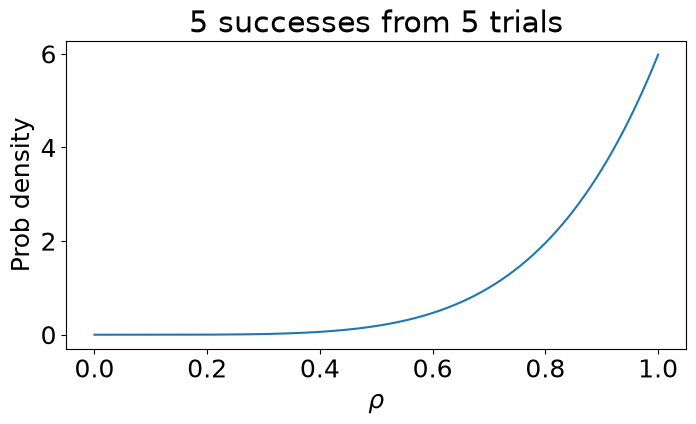

In [11]:
success=5
trials=5

plotrho(trials, success)

If we only make one trial, we don't learn too much!

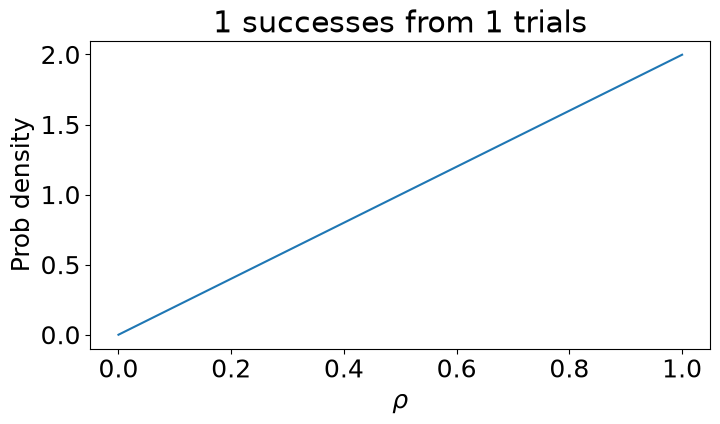

In [12]:
success=1
trials=1

plotrho(trials, success)

If we do many draws (trials) our confidence in $\rho$ increases, i.e. the probability distribution narrows.

Probability that rho is between 0.79 and 0.81: 0.1418656710890111


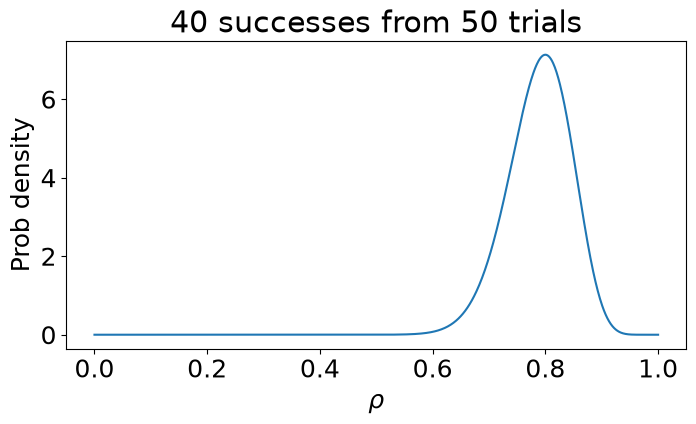

In [13]:
success=40
trials=50

plotrho(trials, success);

print("Probability that rho is between 0.79 and 0.81:", prob_int(trials, success, 0.79,0.81))

Now let's really crank it way up.

Probability that rho is between 0.79 and 0.81: 0.6226388041229822


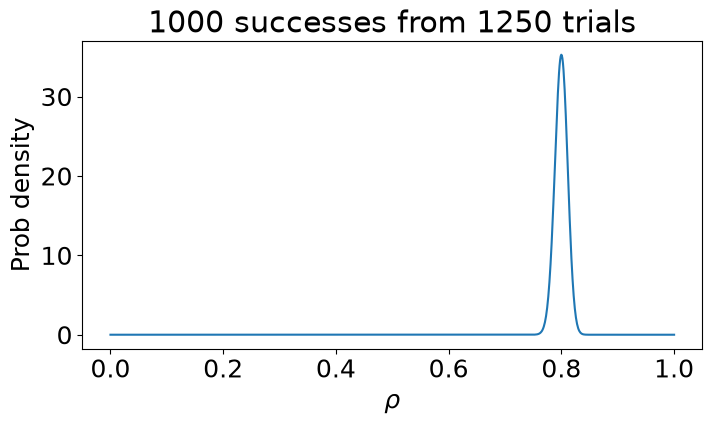

In [14]:
success=1000
trials=1250

plotrho(trials, success);

print("Probability that rho is between 0.79 and 0.81:", prob_int(trials, success, 0.79, 0.81))

This range roughly the 68% confidence interval of $\rho$, i.e. $\rho = 0.80\pm0.01$ for 1250 trials.

We have adopted a Bayesian approach. 

We have introduced a model with one free unknown parameter, the fraction of red balls in the urn, $\rho$. 

And then, from the data (number of trials and successes), we have calculated the probability density function of $\rho$.

Now suppose the urn contains only a finite number of balls, say 10. Then the value of $\rho$ can only take on discrete values (in this example steps of 0.1), or equivalently, $N_{red} = \rho \times 10$.

Suppose I pull 4 reds from 5 draws (with replacement), I can compute the (discrete) probability of the $N_{red}$:


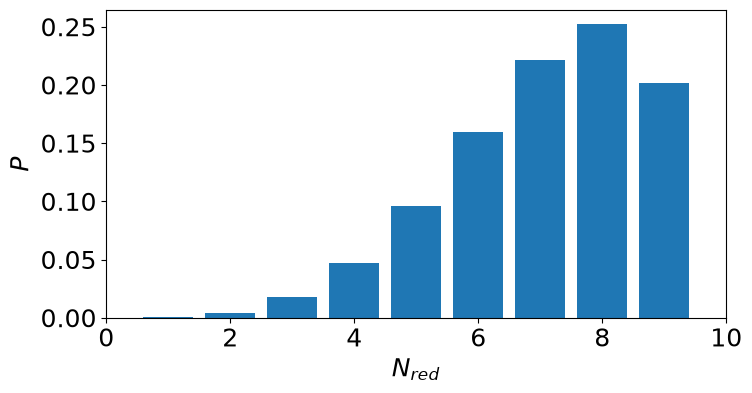

In [15]:
success = 4
trials = 5

nred  = np.linspace(0.,10.,11)

rho = nred/10.
prob = binom(trials,success, rho)
# We are now plotting probability per bin, not probability density
prob = prob/np.sum(prob)

# Let's plot as a histogram
# Note that by default the first argument (nred) is assumed to represent the left edge of teh bin.
# So we use align='center'

plt.xlim((0.,10.))
plt.xlabel(r'$N_{red}$')
plt.ylabel(r'$P$')

plt.bar(nred, prob, align='center');

Implicit in all of the above is what is called a *flat (uniform) prior* on $N_{red}$.

In other words we do not make an prior assumptions on the allowed values of $N_{red}$.

Now suppose a spy had told us "I saw at least 2 white balls placed in the urn. There could be more, but there are at least 2". We now have a *prior* on $N_{red}$: it is between 0 and 8 (can't be 9 or 10 since there are a minimum of 2 white balls). Since we don't know anything else about the number of red balls (or white) we might assume that all remaining possibilities are equally likely.


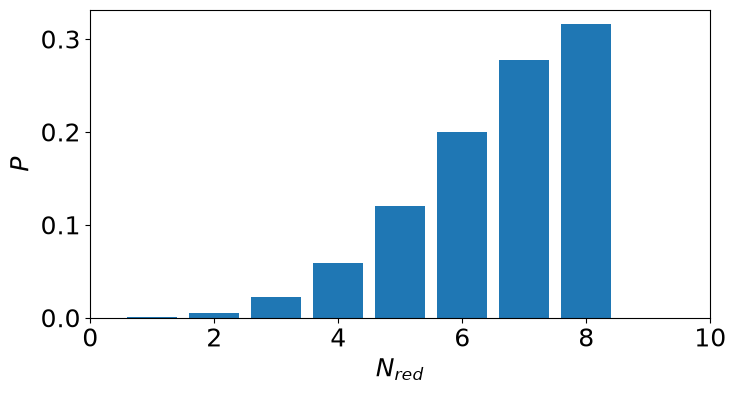

In [16]:
success = 4
trials = 5

nred  = np.linspace(0.,10.,11)

rho = nred/10.
prob = binom(trials,success, rho)
# Renormalize so that we integrate only from 0 to 8.
prob = np.where(nred <=8, prob/sum(prob[:9]), 0.)

plt.xlabel(r'$N_{red}$')
plt.ylabel(r'$P$')
plt.xlim(0,10)
plt.bar(nred,prob, align='center');

The prior has changed the probability distribution, eliminating 9 as a possibility, and boosting all other values.

This may seem trivial, but in real physical situations it can be important. For example, we may expect the mass of an object to be positive or zero, but not negative. We have a _prior_ on the mass.

### Summary

We have introduced several important ideas:

* The idea of independent random variables: in this example each draw is independent of the others. 
    * This is true because we _replaced_ the balls. Had we not replaced them, the subsequent draws would depend on those that came before and they would _not_ be independent.
* Probability of observing an outcome (number of red balls drawn from the urn). Since these are integers this is a discrete probability

* Probability of inferring an unknown _model parameter_ ($\rho$) from the observed data. This is the case most often encountered in science. This is _Bayesian Inference_
* Modifying that probability if we have some _prior_ information (an example of Bayes' Rule)

We have also encountered an example of the central limit theorem:

* _When independent random variables drawn from the same PDF are added, their sum tends toward a normal (or Gaussian) distribution even if the original variables themselves are not normally distributed._

## Basics of Probability Theory

Two kinds of probability:

**Discrete** and **Continuous**

### Discrete probabilities

Examples:
* Roll a die
* Toss a coin
* Number of photons in a CCD pixel
* Is a galaxy a spiral or an elliptical (classification)

$$0 \le P_i \le 1$$

The sum of all probabilities must add up to unity: 
$$
\sum_i P_i = 1
$$

### Continuous probabilities

Examples:
- How long you have to wait for the bus
- The probability that a thrown dart will land some distance from the bull's eye


In physics, continuous probabilities are generally more common.

A continuous probability, say of some value $x$, is described by a function $p(x)$ which gives the "density" of probability per unit of $x$, hence PDF or _Probability Density Function_ .

To get a dimensionless probability, we need to integrate. So for the probability that $x$ lies between $x_1$ and $x_2$ we calculate

\begin{equation}
P(x_1 < x < x_2 ) = \int_{x_1}^{x_2} p(x) \, dx
\end{equation}

For this to make sense the probability must be normalized so that 
$$
P(-\infty < x < \infty ) = \int_{-\infty}^{\infty} p(x) \, dx = 1
$$

The _cumulative distribution function_ (or CDF) is the probability that one is below some upper limit:

$$
P(x < x_1) = \int_{-\infty}^{x_1} p(x) \, dx
$$


### Change of variables

Suppose we have $p(x)$, and we want to write the probability in terms of another variable $y = f(x)$.

So $p(x)dx = p(y)dy$. Therefore

$$
p(y) = p(x) \,\frac{dx}{dy} = p\left(f^{-1}[y]\right) \,\frac{d f^{-1}[y]}{dy}
$$


Example:

$$
y = \exp(x)
$$

$$
x = f^{-1}[y] = \ln(y)
$$

$$
\frac{d f^{-1}[y]}{d y} = \frac{d \ln[y]}{d y} = \frac{1}{y}
$$

![Figure 3.4 from Statistics, Data Mining, and Machine Learning in Astronomy](http://www.astroml.org/_images/fig_transform_distribution_1.png)

Fig 3.4 from SDMMLA: An example of transforming a uniform distribution. In the left panel, $x$ is sampled from a uniform distribution of unit width centered on $x = 0.5$ ($\mu = 0$ and $W = 1$; see Section 3.3.1). In the right panel, the distribution is transformed via $y = \exp(x)$. The form of the resulting pdf is computed from eq. 3.20.

### Moments

For a given PDF $p$, it is useful to define the first and second moments.

Mean:
$$
\mu =  \int_{-\infty}^{\infty} x \, p(x) \, dx
$$

Variance and standard deviation:
$$
\textrm{Var} = \sigma^2 = \int_{-\infty}^{\infty} (x-\mu)^2 \, p(x) \, dx
$$

There are also higher-order moments (e.g. skewness and kurtosis).

More generally the _expectation value_ of any function $f(x)$ is 
$$
\mathrm{E}[f(x)] = \int_{-\infty}^{\infty} f(x) \, p(x) \, dx
$$

so that the mean $\mu$ is just $E[x]$ and the variance is $E[(x-\mu)^2] = E[x^2]-(E[x])^2$

Other ways of characterizing PDFs, particularly location:

    
Mode: where the PDF is maximum

Median:
$$
P(x < x_{\rm median}) = 0.5
$$

More generally other quantiles can be defined.

### Common PDFs

Below are some important PDFs. There is a longer list of the more common ones [here](https://en.wikipedia.org/wiki/Probability_distribution#Common_probability_distributions).

#### Uniform distribution

For a uniform distribution of $x$ between $a$ and $b$ 
$$
U(x) = 1/(b-a)
$$

Mean: $(a+b)/2$

Variance: $(b-a)^2/12$

In [17]:
from scipy.stats import uniform

#Calculate a few first moments
mean, var, skew, kurt = uniform.stats(moments='mvsk')
print("Population:")
print("mean:", mean, "std deviation:", np.sqrt(var))

Population:
mean: 0.5 std deviation: 0.28867513459481287


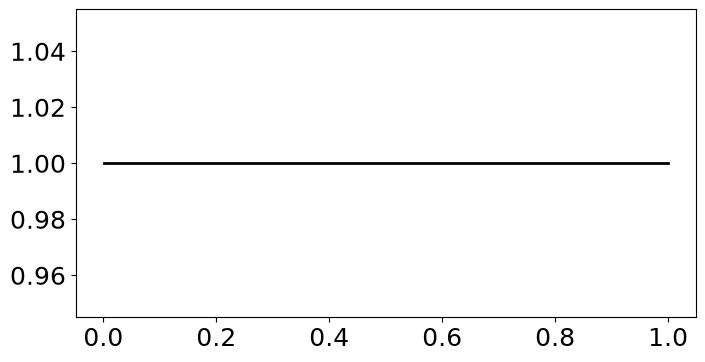

In [18]:
rv = uniform()
x = np.linspace(rv.ppf(0.001), rv.ppf(0.999), 100)
plt.plot(x, rv.pdf(x), 'k-', lw=2, label='pdf');

In [19]:
r = uniform.rvs(size=1000)
print("Sample:")
print("mean:", np.mean(r), "std deviation:", np.std(r))

Sample:
mean: 0.503517944478223 std deviation: 0.27839407599166666


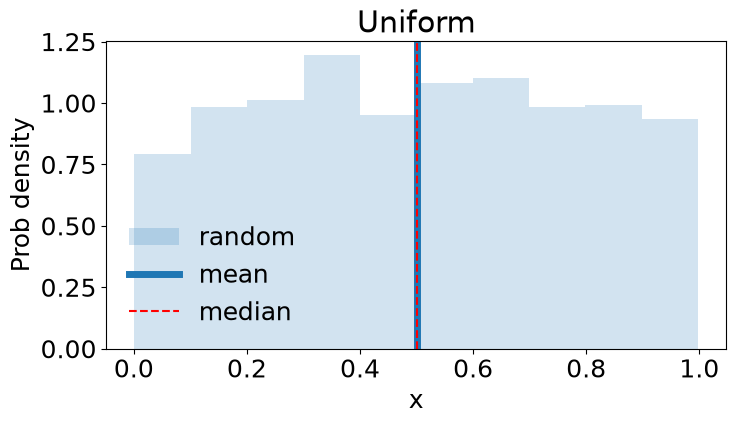

In [20]:
#And compare the histogram:
plt.hist(r, density=True, histtype='stepfilled', alpha=0.2, label='random')

plt.axvline(rv.median(),ls='-', lw=5, label='mean')
plt.axvline(rv.mean(),ls='--', c='r', label='median')
plt.legend(loc='best', frameon=False)
plt.xlabel('x')
plt.ylabel('Prob density')
plt.title('Uniform');

In [21]:
def plotpdf(rvfunc, **kwargs):

    rv = rvfunc(**kwargs)
    mean, var, skew, kurt = rv.stats(moments='mvsk')
    print("Population: mean:", mean, "std deviation:", np.sqrt(var))

    x = np.linspace(rv.ppf(0.0001), rv.ppf(0.9999),100)
    plt.plot(x, rv.pdf(x), 'k-', lw=2, label='pdf');

    r = rv.rvs(size=1000)
    print("Sample: mean:", np.mean(r), "std deviation:", np.std(r))

    #And compare the histogram:
    plt.hist(r, density=True, histtype='stepfilled', alpha=0.2, label='random')
    
    plt.axvline(rv.median(),ls='-', lw=5, label='mean')
    plt.axvline(rv.mean(),ls='--', c='r', label='median')
    plt.axvline(rv.ppf(0.025), ls='--')
    plt.axvline(rv.ppf(0.16), ls='--')
    plt.axvline(rv.ppf(0.84), ls='--')
    plt.axvline(rv.ppf(0.975), ls='--')
    
    plt.legend(loc='best', frameon=False)
    plt.xlabel('x')
    plt.ylabel('Prob density');

#### Normal or Gaussian distribution

(Probably the most important distribution)

\begin{equation}
{\cal N(x | \mu, \sigma}) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
\end{equation}

Mean: $\mu$

Variance: $\sigma^2$ ... with non-trivial higher order moments!

Population: mean: 0.0 std deviation: 1.0
Sample: mean: -0.003793213850062692 std deviation: 0.9803263041742629


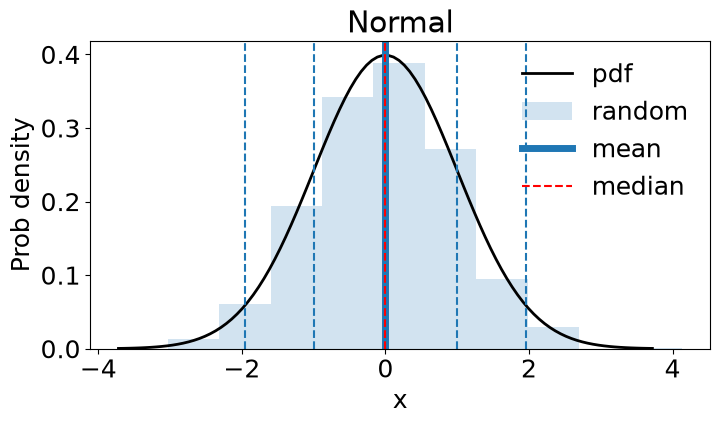

In [22]:
from scipy.stats import norm
plotpdf(norm)
plt.title('Normal');

##### Error bars

$H_0 = 73.24 \pm 1.74$ km/s/Mpc 
[(Reiss et al 2016)](https://ui.adsabs.harvard.edu/#abs/2016ApJ...826...56R/abstract)

What does this mean?

It does not mean: $H_0$ is between 70.5 and 74.98.

It _usually_ means: I think that it's 68% likely that $H_0$ lies between these values, and 95% likely that it's between 68.75 and 76.72.

##### Significant figures and rounding

Quoting something like $H_0 = 73.2456789 \pm 1.7456789$ makes no sense. NEVER ever do this!

But for my taste, Riess et al 2016 slightly overdoes the significant figures.

Rather than quoting $H_0 = 73.24 \pm 1.74$ km/s/Mpc, I would have preferred
$H_0 = 73.2 \pm 1.7$. This is what the [Particle Data Group](https://pdg.lbl.gov/2010/reviews/rpp2010-rev-rpp-intro.pdf) rounding rules give (see their section 5.3)

(Some people would even argue for $H_0 = 73 \pm 2$ but in my view this goes too far.)



Why?

Example: the Planck value is $67$ (with very small uncertainties). 

So, if we use Reiss' numbers, we get a "3.58 $\sigma$" discrepancy between Reiss and Planck. 

If we use the middle choice the discrepancy is "3.65 $\sigma$".

But in the last case it is only "3 $\sigma$": we have lost a half a $\sigma$ in this case.

#### $\chi^2$ distribution

Arises when we square normal (Gaussian) distributions and add them.

Very important for evaluating goodness-of-fit

For small number of degrees of freedom it is quite skewed.

Mean: $k$

Variance: $2k$

Population: mean: 3.0 std deviation: 2.449489742783178
Sample: mean: 2.914565020253814 std deviation: 2.366510134287023


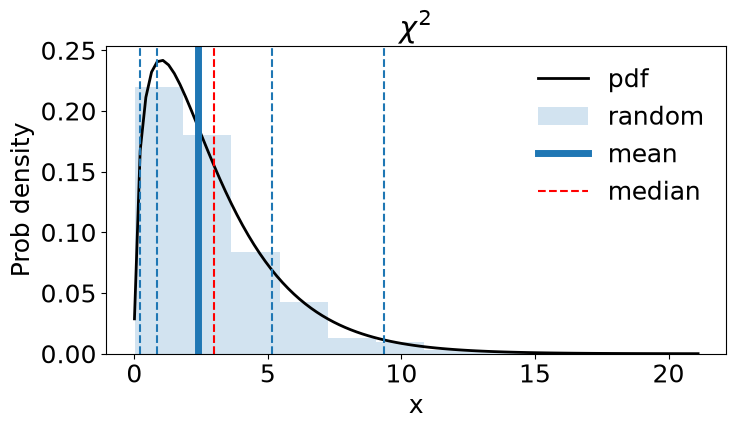

In [23]:
from scipy.stats import chi2
plotpdf(chi2, df=3)
plt.title(r'$\chi^2$');

For the example given in the online survey $\chi^2 = 20$ with 12 datapoints fit with a straight line, dof $= 10$

Population: mean: 10.0 std deviation: 4.47213595499958
Sample: mean: 10.157051091837205 std deviation: 4.4699190481242566


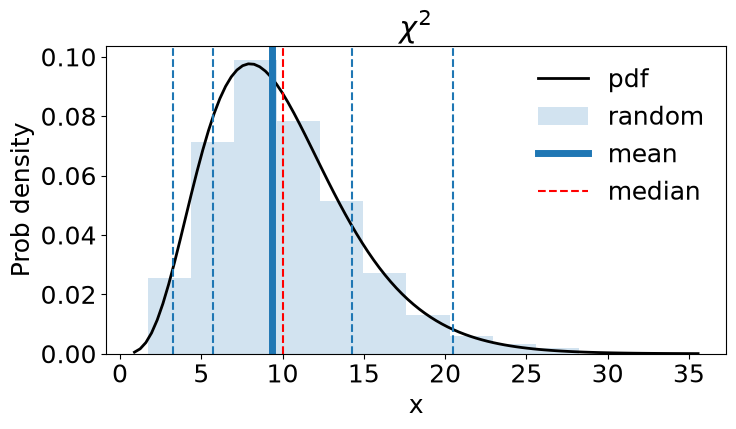

In [24]:
from scipy.stats import chi2
plotpdf(chi2, df=10)
plt.title(r'$\chi^2$');

For large numbers of degrees of freedom it approaches a ...???... distribution

Population: mean: 100.0 std deviation: 14.142135623730951
Sample: mean: 99.48934679349017 std deviation: 14.551238394119409


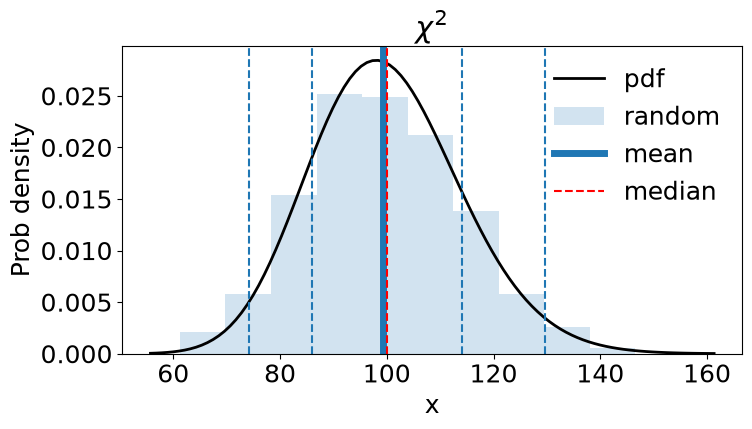

In [25]:
from scipy.stats import chi2
plotpdf(chi2, df=100)
plt.title(r'$\chi^2$');

#### Reduced $\chi^2$

Quoting a reduced 
$$
\chi_{\nu}^2 = \frac{\chi^2}{\nu}
$$ 
(where $\nu$ is d.o.f.) is very common 

.... but **useless**.    

In [26]:
def plotredchi2(dofs):    
    x = np.arange(0.,4.,0.01)
    for k in dofs:
        rv = chi2(df=k)
        line = plt.plot(x, rv.pdf(x*k)*k, label=r'$\nu=$'+str(k))
        line_col = line[0].get_color()
        xlo = rv.ppf(0.025)/k
        xhi = rv.ppf(0.975)/k
        plt.plot([xlo,xlo],[0,rv.pdf(xlo*k)*k],c=line_col,ls=":")
        plt.plot([xhi,xhi],[0,rv.pdf(xhi*k)*k],c=line_col,ls=":")
    plt.legend()
    plt.xlabel(r'$\chi^2_{\nu}$')
    

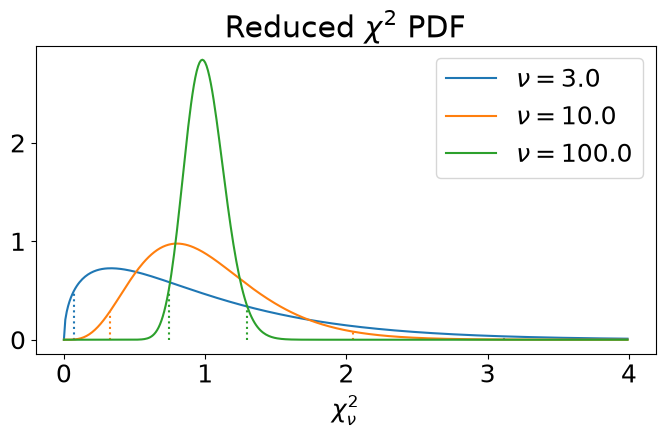

In [27]:
plotredchi2([3.,10.,100.])
plt.title('Reduced '+r'$\chi^2$'+' PDF');

$\chi^2_{\nu} = 1.000 \ldots$ is always acceptable but what about other values? 

For example the value 2 is acceptable if $\nu = 10$ but not if $\nu = 100$.

#### [Poisson distribution](https://en.wikipedia.org/wiki/Poisson_distribution)

The Poisson distribution is a discrete probability distribution that models the number of events, $k$, within some interval (of time, for example) if the _average rate_ over that interval is $\lambda$. $k$ can take discrete values $0, 1, 2 \ldots \infty$

The Poisson distribution can be [derived](https://medium.com/@andrew.chamberlain/deriving-the-poisson-distribution-from-the-binomial-distribution-840cc1668239) from the binomial distribution. Imagine breaking the interval into small chunks and making $n$ trials with probability $p$ of success. Then let $n \rightarrow \infty$ while keeping the rate $\lambda = np$ constant.

An example could be the number of photons that arrive on a given CCD pixel within an exposure time.

$$
P(k \text{ events in interval}) = e^{-\lambda}\frac{\lambda^k}{k!}
$$

In [28]:
def plotpmf(rvfunc, lo=0, hi=10, **kwargs):

    rv = rvfunc(**kwargs)
    mean, var, skew, kurt = rv.stats(moments='mvsk')
    print("mean:", mean, "std deviation:", np.sqrt(var))

    width = 0.4
    x = np.linspace(lo, hi, hi-lo+1)
    plt.bar(x, rv.pmf(x), align='edge', width=width, label='pmf')
    r = rv.rvs(size=1000)

    #And compare the histogram of the random data
    plt.hist(r, bins=np.arange(lo-width/2., hi-width/2.+1, 1),
             density=True, 
             rwidth=width, 
             align='left',
             histtype='bar', 
             alpha=0.2, label='random')
    
    plt.legend(loc='best', frameon=False)
    plt.xlabel('x')
    plt.ylabel('Probability')

mean: 1.0 std deviation: 1.0


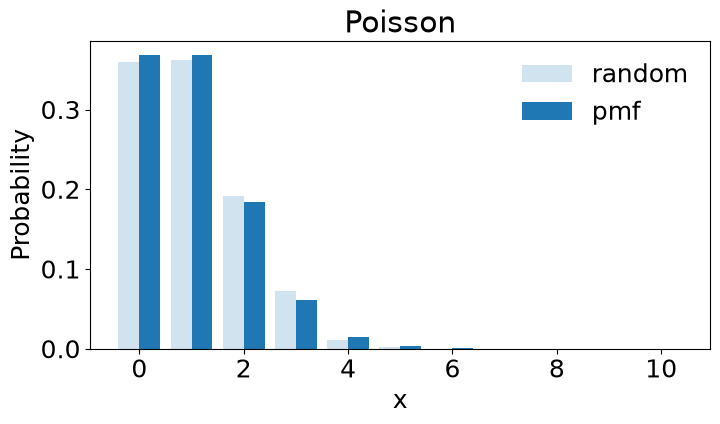

In [29]:
from scipy.stats import poisson
plotpmf(poisson, mu=1.)
plt.title('Poisson');

If $\lambda \ll 1$, then to first order in $\lambda$
$$
P(0) = \exp(-\lambda)  \sim 1-\lambda
$$
$$
P(1) = \lambda \exp(-\lambda) \sim \lambda
$$

mean: 0.1 std deviation: 0.31622776601683794


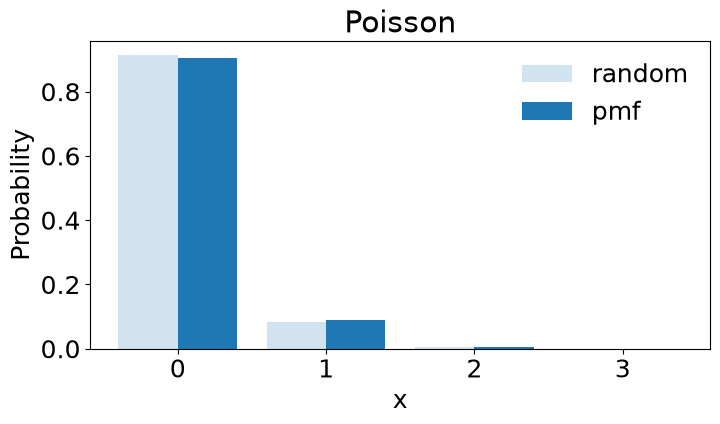

In [30]:
from scipy.stats import poisson
plotpmf(poisson, mu=0.1, hi=3)
plt.title('Poisson');

Poisson Mean: $\lambda$

Poisson Variance: $\lambda$

If I expect $N$ counts in a CCD pixel, the variance is also $N$ so my measurement is $N\pm\sqrt{N}$. 

Because of the ...???..., this approaches Gaussian distribution if $N$ is large. 

mean: 30.0 std deviation: 5.477225575051661


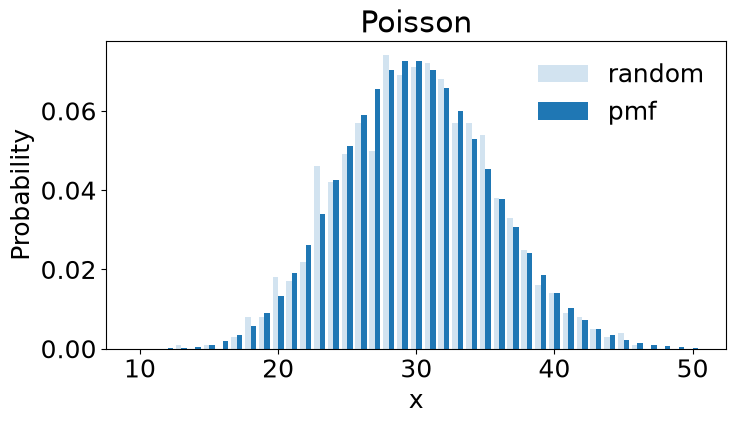

In [31]:
from scipy.stats import poisson
plotpmf(poisson, mu=30., lo=10, hi=50)
plt.title('Poisson');

### Multivariate probabilities, Conditional and Marginal Probabilities and Bayes' Rule

#### Multivariate probabilities

**Discrete case**

As a concrete example, suppose 17 objects might fall into set A or set B or both, as illustrated by the following diagram:

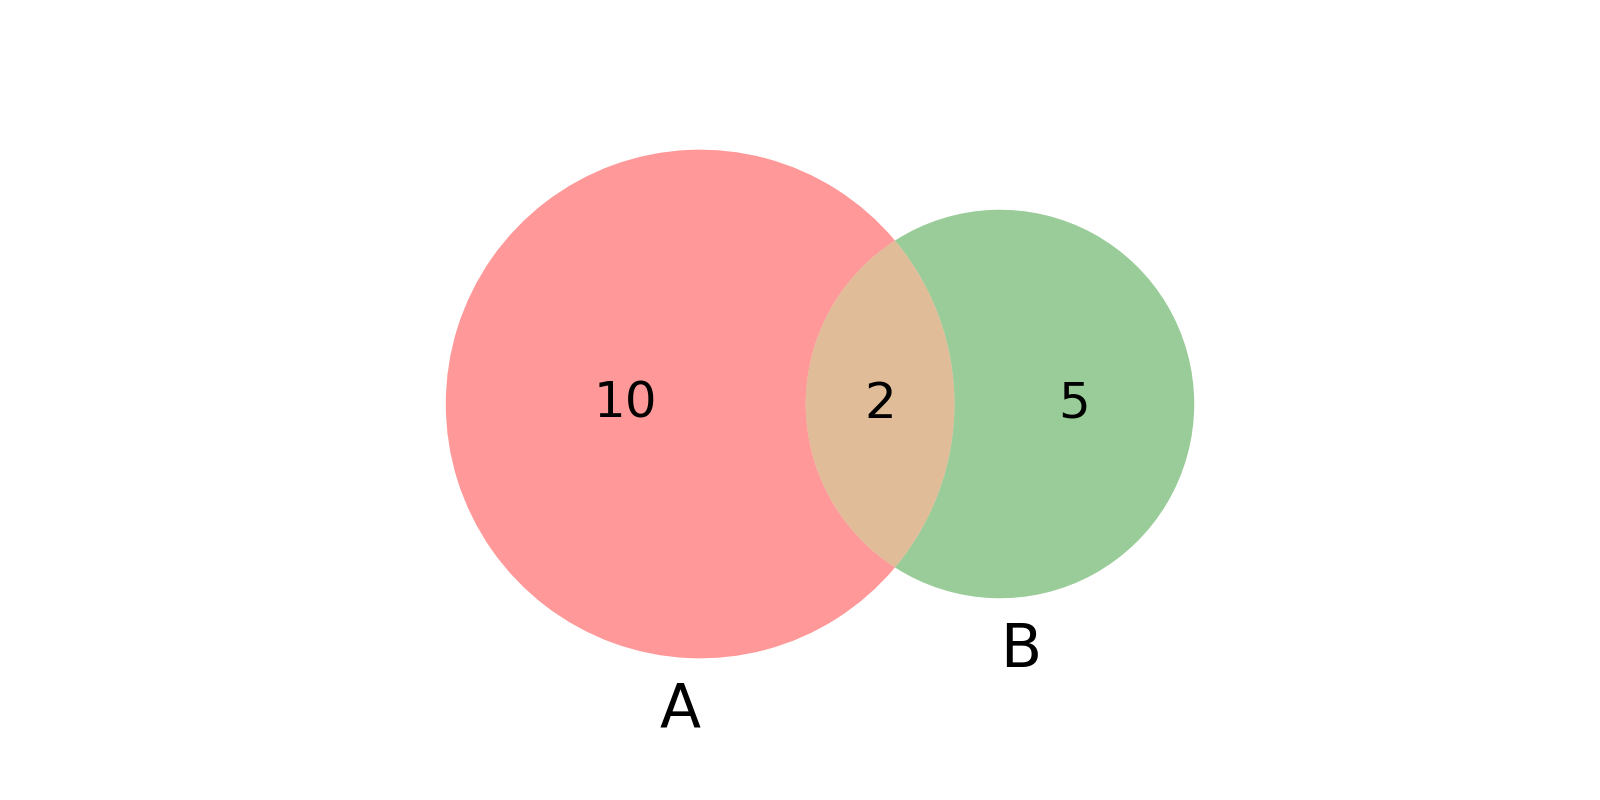

### Conditional probabilities

What is the probability of an item being in set A given that we already know that it is in set B?

This is an example of a _conditional_ probability, $P(A|B)$.

We can write the probability of the intersection of A and B (the _joint_ probability), usually written as $P(A {\rm ~and~} B)$, $P (A \cap B)$, or $P(A,B)$ as follows:

$$
P(A,B) =  P(A|B) \, P(B) = P(B|A) \, P(A)
$$

For example, using the numbers from the diagram above,
$P(A, B) = 2/17$. 

Now $P(B) = 7/17$, and $P(A|B) = 2/7$, so the first equation works. 

Also $P(B|A) = 2/12$, and $P(A) = 12/17$, so does the second.

Rearranging
$$
P(A,B) =  P(A|B) \, P(B) = P(B|A) \, P(A)
$$

leads to the usual form of **Bayes' Rule** (or Law or Theorem)

\begin{equation}
P(A|B) = \frac{P(B|A) P(A)}{P(B)}
\end{equation}

In a similar way, we can also define a joint probability density for _continuous_ variables:

$$
p(x,y) = p(y|x)\,p(x) = p(x|y)\,p(y)
$$

where we must have
\begin{equation*}
\int_x \int_y p(x,y) \; dy \; dx= 1
\end{equation*}

This is a surface density, so $p(x,y)$ has units of $\frac{1}{(\text{units of}~x) (\text{units of}~y)}$.

We can get the _marginal probability_ $p(x)$ from the joint probability $p(x,y)$ by _marginalizing_ (integrating) over $y$:

\begin{equation*}
p(x) = \int_y p(x,y) \; dy = \int_y  p(x|y)\,p(y) \; dy
\end{equation*}

So Bayes' Rule can be written:
$$
p(y|x) = \frac{p(x|y)\,p(y)}{p(x)} = \frac{p(x|y)\,p(y)}{\int_y p(x|y)\,p(y) \; dy}
$$

If $p(y|x) = p(y)$ then $x$ and $y$ are independent. 

Then it follows from Bayes' Rule that $p(x|y) = p(x)$ and that
$p(x,y) = p(x) p(y)$

![Conditional and marginal probabilities](http://www.astroml.org/_images/fig_conditional_probability_1.png)


Figure 3.2.

An example of a two-dimensional probability distribution. The color-coded panel shows $p(x, y)$. The two panels to the left and below show marginal distributions in $x$ and $y$ (see eq. 3.8). The three panels to the right show the conditional probability distributions $p(x|y)$ (see eq. 3.7) for three different values of $y$ (as marked in the left panel).


#### Examples of multivariate distributions

##### Multivariate Normal

In general the multivariate Normal for a vector of length $k$ 

$$
{\cal N}(x_1,\ldots,x_k) = \frac{\exp\left(-\frac 1 2 ({\mathbf x}-{\boldsymbol\mu})^\mathrm{T}{\boldsymbol\Sigma}^{-1}({\mathbf x}-{\boldsymbol\mu})\right)}{\sqrt{(2\pi)^k|\boldsymbol\Sigma|}}
$$

where ${\mathbf x}$ is a $k$-dimensional column vector, and $|\boldsymbol\Sigma|\equiv \operatorname{det}\boldsymbol\Sigma$ is the determinant of $\boldsymbol\Sigma$. 

$\boldsymbol\Sigma$ is the covariance matrix. It has the _variances_ of each component of ${\mathbf x}$ along its diagonal.

The equation above reduces to that of the univariate normal distribution if $\boldsymbol\Sigma$ is a $1 \times 1$ matrix (i.e. a single real number).

##### Bivariate Normal
Easier to follow is the _bivariate_ normal distribution

$$
{\cal N}(x,y) = \frac{1}{2 \pi  \sigma_x \sigma_y \sqrt{1-\rho^2}} \exp(-z^2) 
$$

where 

$$
z^2 = -\frac{1}{2(1-\rho^2)}\left[
          \frac{(x-\mu_x)^2}{\sigma_x^2} +
          \frac{(y-\mu_y)^2}{\sigma_y^2} -
          \frac{2\rho(x-\mu_x)(y-\mu_y)}{\sigma_x \sigma_y}
        \right]\;,
$$

where $\rho$ is the Pearson correlation between $x$ and $y$ and
where $\sigma_x>0$ and $\sigma_y>0$. 

In this case, we can relate these values to the covariance matrix $\boldsymbol\Sigma$
$$
    \boldsymbol\mu = \begin{pmatrix} \mu_x \\ \mu_y \end{pmatrix}, \quad
    \boldsymbol\Sigma = \begin{pmatrix} \sigma_x^2 & \rho \sigma_x \sigma_y \\
                             \rho \sigma_x \sigma_y  & \sigma_y^2 \end{pmatrix}.
$$

In [ ]:
# Adapted by Mike Hudson from original by
#
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from astroML.stats.random import bivariate_normal
from matplotlib.patches import Ellipse

#------------------------------------------------------------
# Define the mean, principal axes, and rotation of the ellipse
mean = np.array([0, 0])
sigma_1 = 2.
sigma_2 = 1.
alpha = -np.pi / 6.

#------------------------------------------------------------
# Draw 10^5 points from a multivariate normal distribution
#
#   we use the bivariate_normal function from astroML.  A more
#   general function for this is numpy.random.multivariate_normal(),
#   which requires the user to specify the full covariance matrix.
#   bivariate_normal() generates this covariance matrix for the
#   given inputs.
np.random.seed(0)
x, cov = bivariate_normal(mean, sigma_1, sigma_2, alpha, 
                          size=100000, return_cov=True)

sigma_x = np.sqrt(cov[0, 0])
sigma_y = np.sqrt(cov[1, 1])
sigma_xy = cov[0, 1]

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)

# plot a 2D histogram/hess diagram of the points
H, bins = np.histogramdd(x, bins=2 * [np.linspace(-4.5, 4.5, 51)])
ax.imshow(H.T, origin='lower', cmap=plt.cm.binary, 
          interpolation='nearest',
          extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]])

# draw 1, 2, 3-sigma ellipses over the distribution
for N in (1, 2, 3):
    ax.add_patch(Ellipse(mean, N * sigma_1, N * sigma_2,
                         angle=alpha * 180. / np.pi, lw=1,
                         ec='k', fc='none'))

kwargs = dict(ha='left', va='top', transform=ax.transAxes)

ax.text(0.02, 0.98, r"$\sigma_1 = %i$" % sigma_1, **kwargs)
ax.text(0.02, 0.93, r"$\sigma_2 = %i$" % sigma_2, **kwargs)
ax.text(0.02, 0.88, r"$\alpha = \pi / %i$" % (np.pi / alpha), **kwargs)

ax.text(0.5, 0.98, r"$\sigma_x = %.2f$" % sigma_x, **kwargs)
ax.text(0.5, 0.93, r"$\sigma_y = %.2f$" % sigma_y, **kwargs)
ax.text(0.5, 0.88, r"$\sigma_{xy} = %.2f$" % sigma_xy, **kwargs)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$');